In [6]:
import json
from typing import Sequence

import agama
import gc_utils
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import utilities as ut
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

In [2]:
sim = "m12i"
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
snap_lim = 102
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].values
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].values

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

agama.setUnits(mass=1, length=1, velocity=1)

In [3]:
pot_dict = {sim: [] for sim in sim_lst}

for sim in sim_lst:
    for snap in snap_lst:
        pot_fil = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
        pot_nbody = agama.Potential(pot_fil)
        pot_dict[sim].append(np.abs(pot_nbody.potential([0, 0, 0])))

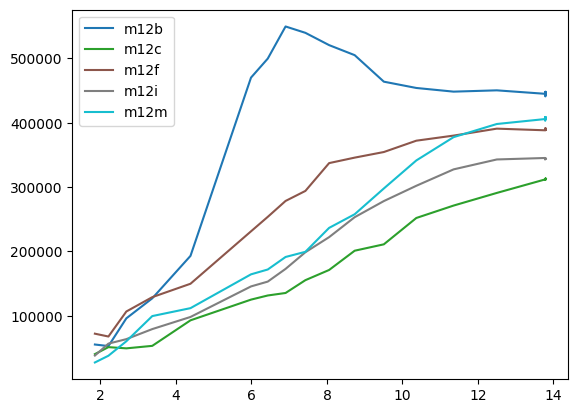

In [5]:
for i, sim in enumerate(pot_dict.keys()):
    plt.plot(time_lst, pot_dict[sim], c=colors[i], label=sim)

plt.legend()

array([ 1.85183633,  2.21035546,  2.68527705,  3.37228352,  4.38467705,
        5.98814366,  6.43194407,  6.90376726,  7.42876967,  8.0576176 ,
        8.73476537,  9.50745578, 10.36813558, 11.35578917, 12.50060116,
       13.77655646])

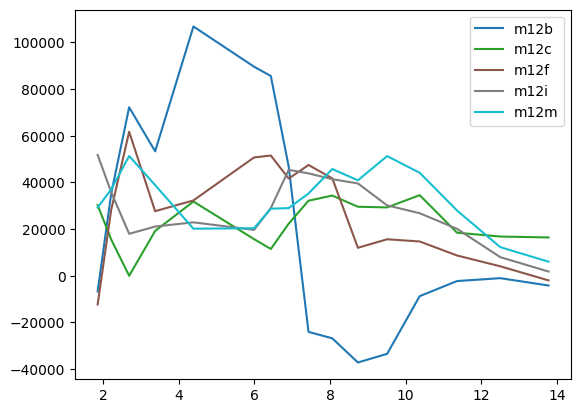

In [17]:
for i, sim in enumerate(pot_dict.keys()):
    grad = np.gradient(pot_dict[sim][:-10], time_lst[:-10])
    plt.plot(time_lst[:-10], grad, c=colors[i], label=sim)

plt.legend()

In [10]:
# dictionary to store FWHM
fwhm_dict = {sim: [] for sim in sim_lst}

r_max = 100.0  # max radius to sample, adjust to your system
n_r = 500  # number of radial points

for sim in sim_lst:
    for snap in snap_lst:
        pot_fil = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
        pot_nbody = agama.Potential(pot_fil)

        # radial sampling
        r = np.linspace(0, r_max, n_r)
        phi_r = np.array([pot_nbody.potential([ri, 0, 0]) for ri in r])

        # handle negative potentials: FWHM based on depth
        phi_center = phi_r[0]
        phi_edge = phi_r[-1]
        phi_half = 0.5 * (phi_center + phi_edge)  # halfway between center and edge

        # interpolate to find radius at half-maximum
        interp_func = interp1d(phi_r, r)
        r_half = interp_func(phi_half)

        # FWHM is twice the half-radius (assuming symmetry)
        fwhm = 2 * r_half
        fwhm_dict[sim].append(fwhm)

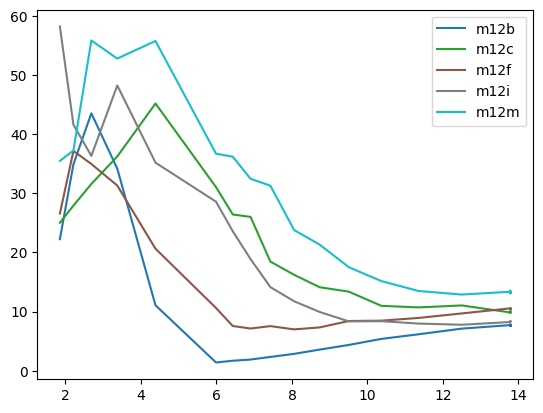

In [11]:
for i, sim in enumerate(fwhm_dict.keys()):
    plt.plot(time_lst, fwhm_dict[sim], c=colors[i], label=sim)

plt.legend()

In [18]:
# Dictionary to store steepness
steepness_dict = {sim: [] for sim in sim_lst}

r_max = 50  # max radius to sample
n_r = 100  # number of radial points
r_inner_max = 10  # radius within which to measure steepness (kpc)

for sim in sim_lst:
    for snap in snap_lst:
        # Load potential
        pot_fil = f"{sim_dir}{sim}/potentials/snap_{snap}/combined_snap_{snap}.ini"
        pot_nbody = agama.Potential(pot_fil)

        # Radial sampling along x-axis
        r = np.linspace(0, r_max, n_r)
        coords = np.column_stack([r, np.zeros_like(r), np.zeros_like(r)])
        phi_r = pot_nbody.potential(coords)

        # Compute radial derivative of potential
        dphi_dr = np.gradient(phi_r, r)

        # Select inner region
        inner_mask = r <= r_inner_max

        # Average absolute slope in inner region = steepness
        steepness_value = np.mean(np.abs(dphi_dr[inner_mask]))
        steepness_dict[sim].append(steepness_value)


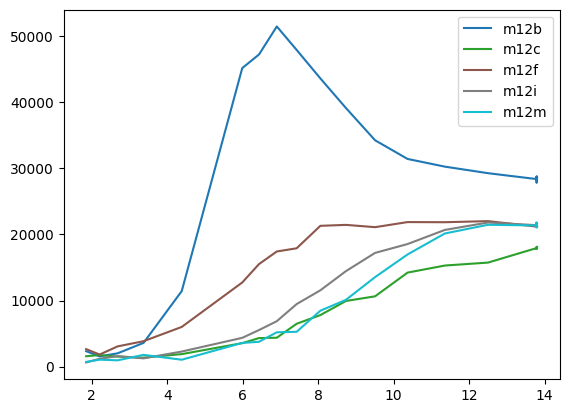

In [19]:
for i, sim in enumerate(steepness_dict.keys()):
    plt.plot(time_lst, steepness_dict[sim], c=colors[i], label=sim)

plt.legend()